In [1]:
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
df = pd.read_csv('/content/fitness_data.csv')
df.head()


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4,1


In [3]:
df.columns


Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature', 'liked'],
      dtype='object')

In [6]:
df['anomaly'] = 1  # 1 = normal

# Energy-based anomaly (Heart rate proxy)
energy_low = df['energy'].quantile(0.05)
energy_high = df['energy'].quantile(0.95)

# Duration-based anomaly (Sleep proxy)
duration_low = df['duration_ms'].quantile(0.05)
duration_high = df['duration_ms'].quantile(0.95)

df.loc[
    (df['energy'] < energy_low) |
    (df['energy'] > energy_high) |
    (df['duration_ms'] < duration_low) |
    (df['duration_ms'] > duration_high),
    'anomaly'
] = -1   # -1 = anomaly


In [7]:
df['anomaly'].value_counts()


,count
anomaly,
1,158
-1,37


In [8]:
hr_normal = df[df['anomaly'] == 1]
hr_anomaly = df[df['anomaly'] == -1]


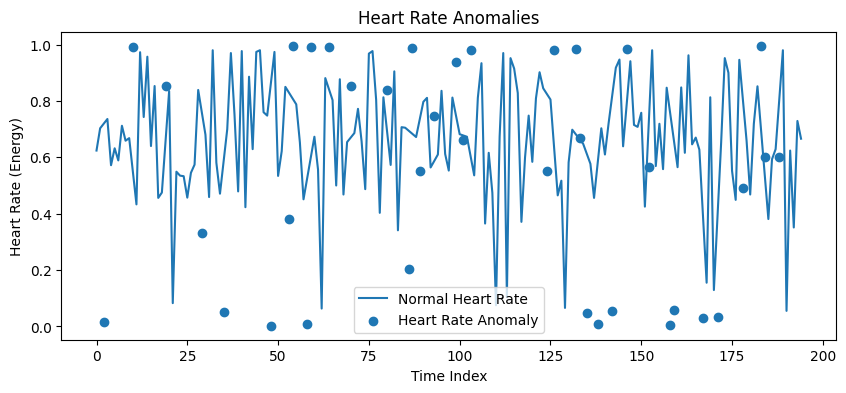

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(hr_normal.index,
         hr_normal['energy'],
         label='Normal Heart Rate')

plt.scatter(hr_anomaly.index,
            hr_anomaly['energy'],
            label='Heart Rate Anomaly')

plt.xlabel("Time Index")
plt.ylabel("Heart Rate (Energy)")
plt.title("Heart Rate Anomalies")
plt.legend()
plt.show()


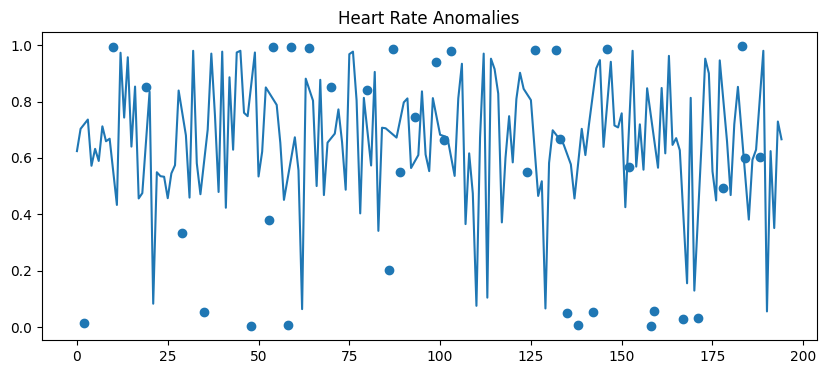

In [10]:
plt.figure(figsize=(10,4))
plt.plot(hr_normal.index, hr_normal['energy'])
plt.scatter(hr_anomaly.index, hr_anomaly['energy'])
plt.title("Heart Rate Anomalies")
plt.savefig("heart_rate_anomalies.png")
plt.show()


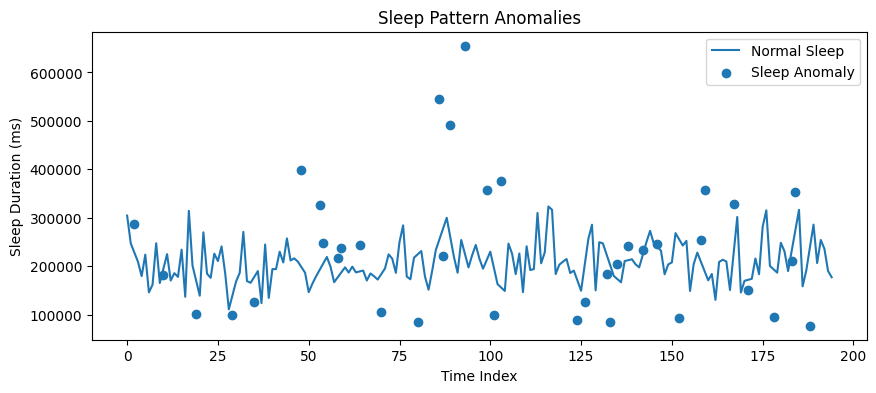

In [11]:
plt.figure(figsize=(10,4))

plt.plot(hr_normal.index,
         hr_normal['duration_ms'],
         label='Normal Sleep')

plt.scatter(hr_anomaly.index,
            hr_anomaly['duration_ms'],
            label='Sleep Anomaly')

plt.xlabel("Time Index")
plt.ylabel("Sleep Duration (ms)")
plt.title("Sleep Pattern Anomalies")
plt.legend()
plt.show()


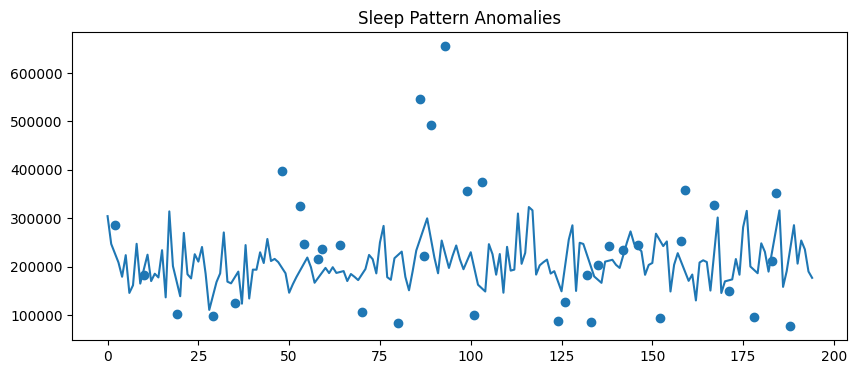

In [12]:
plt.figure(figsize=(10,4))
plt.plot(hr_normal.index, hr_normal['duration_ms'])
plt.scatter(hr_anomaly.index, hr_anomaly['duration_ms'])
plt.title("Sleep Pattern Anomalies")
plt.savefig("sleep_anomalies.png")
plt.show()
